# Imports

In [42]:
import sys
import os

#sys.path.append("/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/")

import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, TwoSlopeNorm


import numpy as np

#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")

#sys.path.insert(0,"/software/local/languages/miniforge3/envs/tensorflow/lib/python3.12/site-packages")

sys.path.insert(0,"/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/")

sys.path.insert(0,"/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages")

sys.path.insert(0, "/user/work/kr21883/")


print(sys.path)

import torch
import os
import pickle
import einops


import xarray as xr
from glob import glob
from scipy.stats import pearsonr
import matplotlib.animation as animation

#import plenoptic as po

#sys.path.insert(0, "/user/work/kr21883/GCN/graphnet/")
from graphnet_LPDM_emulator.model.layers.encoder import *
from graphnet_LPDM_emulator.model.layers.decoder import *
from graphnet_LPDM_emulator.model.layers.processor import *
from graphnet_LPDM_emulator.model.layers.graph_net_block import *
from graphnet_LPDM_emulator.model.data.dataloader_graphnet import *
from graphnet_LPDM_emulator.model.data.load_data import *
from graphnet_LPDM_emulator.model.forecast import GraphSatelliteForecaster
from graphnet_LPDM_emulator.model.loss_functions import *
from graphnet_LPDM_emulator.model.evaluation import *
from graphnet_LPDM_emulator.model.metrics_and_figures import *

import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import time
from datetime import datetime
import json
import argparse

import random

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import timeit

['/user/work/kr21883/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/kr21883/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/kr21883/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/kr21883/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/ef17148/oldstuff/ef17148/

# Functions

In [11]:
def plot_mean_with_uncertainty(ax, models, key, label=None, color=None, max_len=100):
    ### For the training metrics
    values = []
    for mod in models:
        if key in mod:
            data = mod[key]
            if isinstance(data, dict):
                data = data["R2"]
            values.append(np.array(data[:max_len]))
    
    if not values:
        return

    values = np.stack(values)  # shape: (num_models, time)
    mean = np.mean(values, axis=0)
    std = np.std(values, axis=0)

    x = np.arange(len(mean))
    ax.plot(x, mean, label=label, color=color)
    ax.fill_between(x, mean - std, mean + std, alpha=0.3, color=color)


# Local helper function to save inside summary_outputs
def save_path(filename):
    return os.path.join(summary_dir, filename)

# For animated visualation of uncertainty
def animate_dataarray(da, title_prefix, filename, cmap="viridis", interval=300, vmin=None, vmax=None, save_dir="."):
    """
    Creates and saves an animation of a spatio-temporal xarray.DataArray.

    Parameters:
    - da: xarray.DataArray with dimensions including 'time', 'lat', and 'lon'
    - title_prefix: string, e.g., 'Mean Prediction'
    - filename: string, e.g., 'mean_prediction.gif'
    - cmap: matplotlib colormap string
    - interval: int, milliseconds between frames
    - vmin, vmax: floats, fixed colorbar limits (optional)
    - save_dir: directory to save the gif in
    """

    fig, ax = plt.subplots()
    da0 = da.isel(time=0)
    img = da0.plot(ax=ax, cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(img, ax=ax)
    cbar.set_label(title_prefix)

    def update(frame_idx):
        ax.clear()
        da_frame = da.isel(time=frame_idx)
        da_frame.plot(ax=ax, cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
        ax.set_title(f"{title_prefix} - Time {frame_idx}")
        return ax

    ani = animation.FuncAnimation(fig, update, frames=da.sizes["time"], interval=interval)
    output_path = os.path.join(save_dir, filename)
    ani.save(output_path, writer="pillow")
    plt.close()
    print(f"Saved animation: {output_path}")

# Setup

In [12]:
variable_to_compare = "predictions" ####
disagreement_threshold = 0.003
epsilon = 1e-6  # for coefficient of variation to avoid division by zero

summary_dir = os.path.join("uncertainty/summary_outputs")
os.makedirs(summary_dir, exist_ok=True)

# time steps to plot
time_steps = [0,1,2]
single_time_step = time_steps[0]

# List of model names
model_names = [
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B",
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5",
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100",
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33"
]

# comparing the losses across models

In [13]:
# four models to compare, each with a different seed 
# note that they all do have the same parameters even if the first is called _B, it was just an error in naming!!
loss_weiB = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B")
loss_weiB["name"] = "Seed 34"
loss_weiC5 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5")
loss_weiC5["name"] = "Seed 5"
loss_weiC100 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100")
loss_weiC100["name"] = "Seed 100"
loss_weiC33 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33")
loss_weiC33["name"] = "Seed 33"

loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33


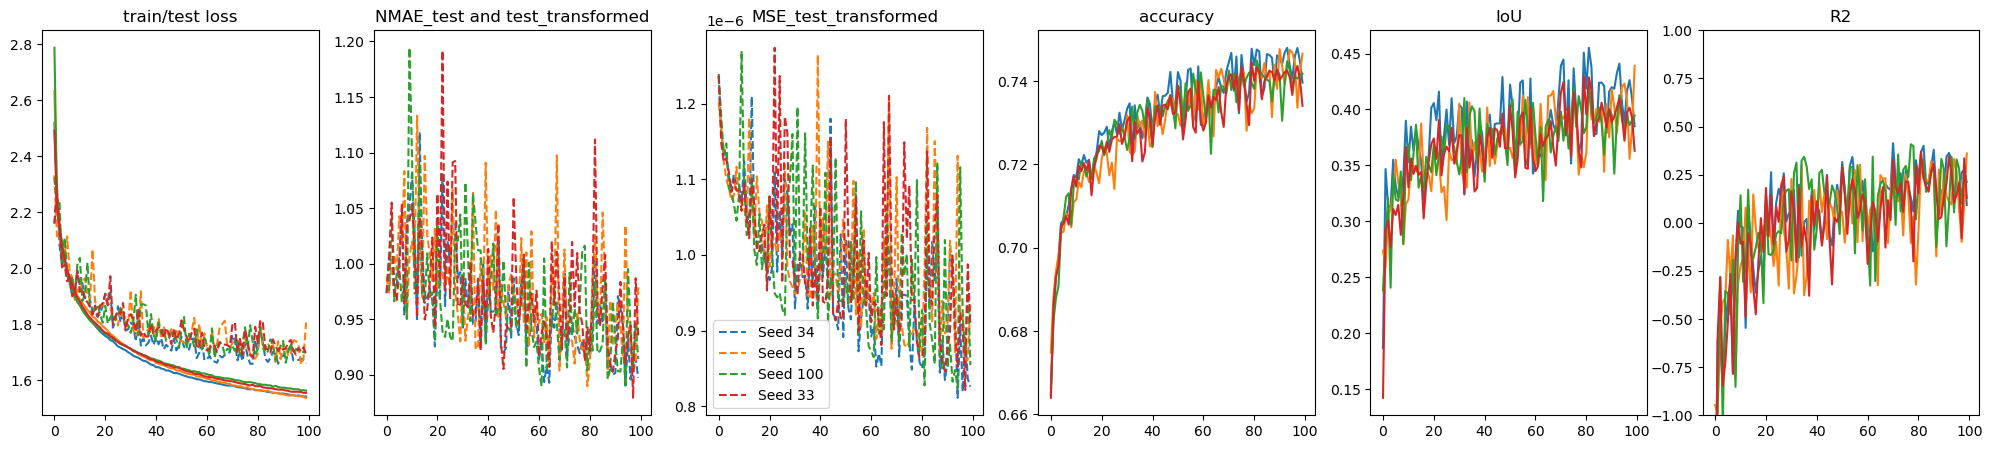

In [14]:
models_to_plot = [loss_weiB, loss_weiC5, loss_weiC100, loss_weiC33]
fig, ax = plt.subplots(1,6, figsize = (25,5))
for mod in models_to_plot:
    if "train" in list(mod.keys()):
        p, = ax[0].plot(mod["train"][:100])
        ax[0].plot(mod["test"][:100], "--", c=p.get_color()) 
    #if "NMAE_test" in list(mod.keys()):
    #    ax[1].plot(abs(np.array(mod["NMAE_test"])), c=p.get_color())  
    if "NMAE_test_transformed" in list(mod.keys()):
        ax[1].plot(abs(np.array(mod["NMAE_test_transformed"]))[:100], "--", c=p.get_color())       
    if "MSE_test_transformed" in list(mod.keys()):
        ax[2].plot(abs(np.array(mod["MSE_test_transformed"]))[:100], "--", c=p.get_color(), label=mod["name"])    
    if "accuracy" in list(mod.keys()):
        ax[3].plot(abs(np.array(mod["accuracy"]))[:100], c=p.get_color())    
    if "IoU" in list(mod.keys()):
        ax[4].plot(abs(np.array(mod["IoU"]))[:100], c=p.get_color())   
    if "flux_uniform" in list(mod.keys()):
        ax[5].plot(mod["flux_uniform"]["R2"][:100], c=p.get_color())   
    

ax[0].set_title("train/test loss")
ax[1].set_title("NMAE_test and test_transformed")
ax[2].set_title("MSE_test_transformed")
ax[3].set_title("accuracy")
ax[4].set_title("IoU")
ax[5].set_title("R2")
ax[5].set_ybound(-1,1)
ax[2].legend()

### Aggregating: Plot mean + SD for training metrics

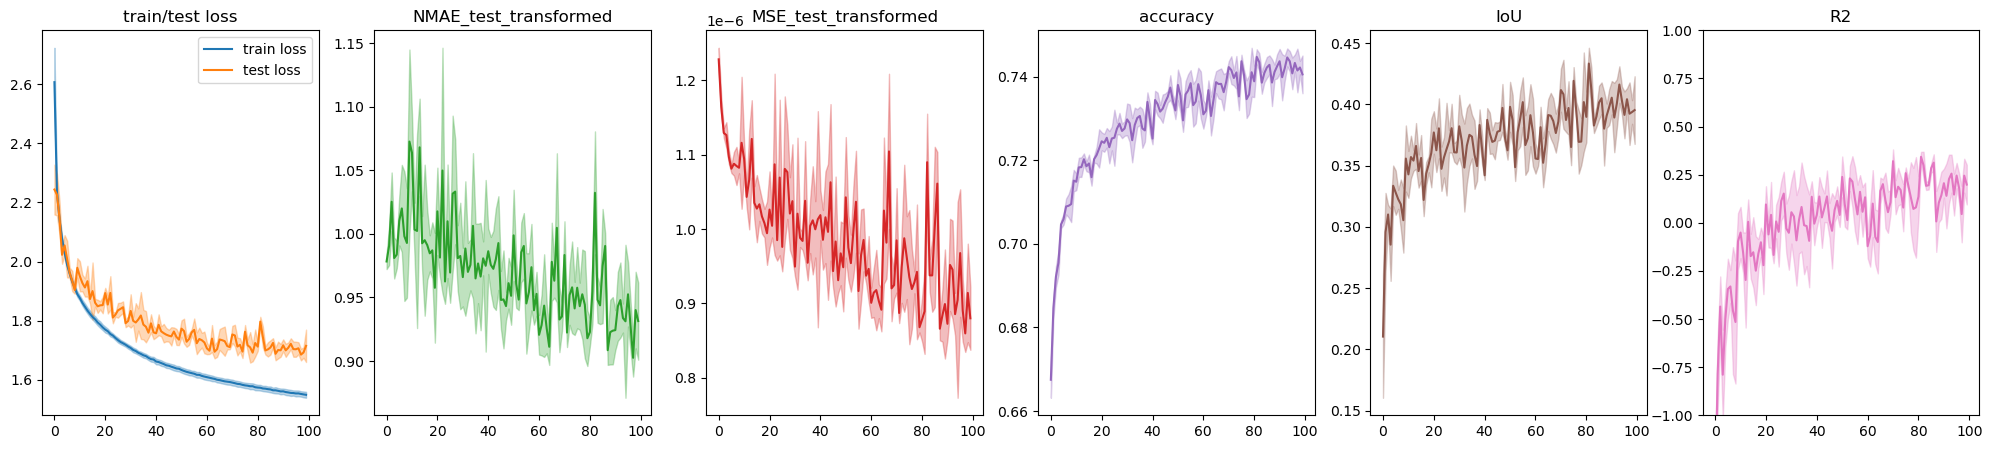

Saved model_training_uncertainty.png


In [15]:
colours = plt.cm.tab10.colors

# Create a new figure for uncertainty plots
fig2, ax2 = plt.subplots(1,6, figsize=(25,5))

plot_mean_with_uncertainty(ax2[0], models_to_plot, "train", label="train loss", color=colours[0])
plot_mean_with_uncertainty(ax2[0], models_to_plot, "test", label="test loss", color=colours[1])
ax2[0].set_title("train/test loss")
ax2[0].legend()

plot_mean_with_uncertainty(ax2[1], models_to_plot, "NMAE_test_transformed", label="NMAE", color=colours[2])
ax2[1].set_title("NMAE_test_transformed")

plot_mean_with_uncertainty(ax2[2], models_to_plot, "MSE_test_transformed", label="MSE", color=colours[3])
ax2[2].set_title("MSE_test_transformed")

plot_mean_with_uncertainty(ax2[3], models_to_plot, "accuracy", label="accuracy", color=colours[4])
ax2[3].set_title("accuracy")

plot_mean_with_uncertainty(ax2[4], models_to_plot, "IoU", label="IoU", color=colours[5])
ax2[4].set_title("IoU")

plot_mean_with_uncertainty(ax2[5], models_to_plot, "flux_uniform", label="R2", color=colours[6])
ax2[5].set_title("R2")
ax2[5].set_ybound(-1, 1)

plt.savefig(save_path("model_training_uncertainty.png"))
plt.show()
plt.close()
print(f"Saved model_training_uncertainty.png")



# loading the data for one of the models

In [44]:
model_name = "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5"
mod = ModelEv(model_name, size=50, validation_set="0[1-3]", test_set="*", val_year="2016", test_year="2016", check_validation_overlap=True, path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/")
# loads the model into a ModelEv object. by default it has the parameters above, which validate on Jan-March (stored in mod.preds_val) and keeps the rest in mod.preds_test 
# setting "check_validation_overlap=False" will keep all the footprints in mod.preds_test

loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


In [53]:
mod.preds_test

<xarray.Dataset>
Dimensions:            (time: 4243, lat: 50, lon: 50)
Coordinates:
  * time               (time) datetime64[ns] 2016-04-01T15:29:20 ... 2016-12-...
  * lat                (lat) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lon                (lon) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
Data variables:
    predictions        (time, lat, lon) float32 -2.114 -2.18 ... 0.1506 0.5178
    trans_predictions  (time, lat, lon) float32 6.109e-07 ... 0.0003045
    fp                 (time, lat, lon) float64 6.866e-05 ... 0.0002823
    trans_fp           (time, lat, lon) float32 -0.1285 -0.0415 ... 0.4849
Attributes:
    creation_date:  2024-02-11 15:41:59.635325

In [17]:
"""
mod.preds_test has a naming structure (i acknowledge, confusing):
- fps: the original footprints (native data space)
- trans_fp: the original footprints, transformed according to the input transform (transformed data space)
- predictions: the predictions of the model, untouched (transformed data space)
- trans_predictions: the predictions of the model, transformed back to the original data space (native data space)
"""
mod.preds_test

<xarray.Dataset>
Dimensions:            (time: 4243, lat: 50, lon: 50)
Coordinates:
  * time               (time) datetime64[ns] 2016-04-01T15:29:20 ... 2016-12-...
  * lat                (lat) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lon                (lon) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
Data variables:
    predictions        (time, lat, lon) float32 -2.114 -2.18 ... 0.1506 0.5178
    trans_predictions  (time, lat, lon) float32 6.109e-07 ... 0.0003045
    fp                 (time, lat, lon) float64 6.866e-05 ... 0.0002823
    trans_fp           (time, lat, lon) float32 -0.1285 -0.0415 ... 0.4849
Attributes:
    creation_date:  2024-02-11 15:41:59.635325

In [18]:
# threshold the model to remove the lower values. stores these predictions in mod.pred_fluxes["thr"]
mod.get_adjusted_models(which="thr_only")

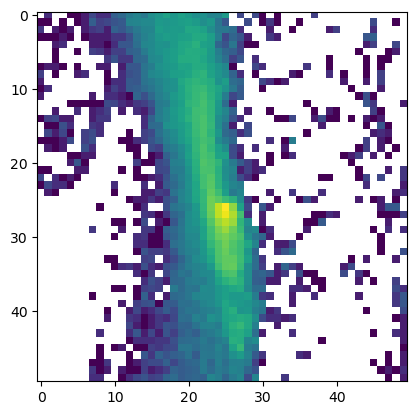

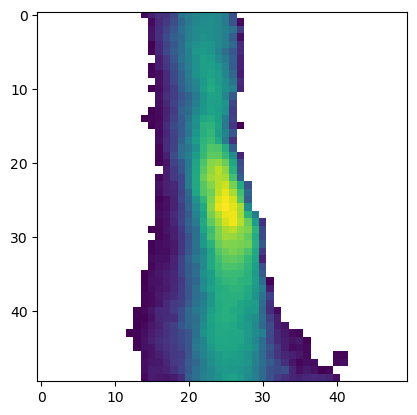

In [19]:
t = 16#t+5
plt.imshow(np.log10(mod.preds_test.fp[t]))
plt.show()
plt.imshow(np.log10(mod.preds_test.thr[t]))
plt.show()

In [20]:
# get fluxes by default calculates uniform fluxes, ie summing over the footprints
mod.get_fluxes()

using UNIFORM fluxes!
USING NO UNITS TRANSFORM on the fluxes! this may have changed


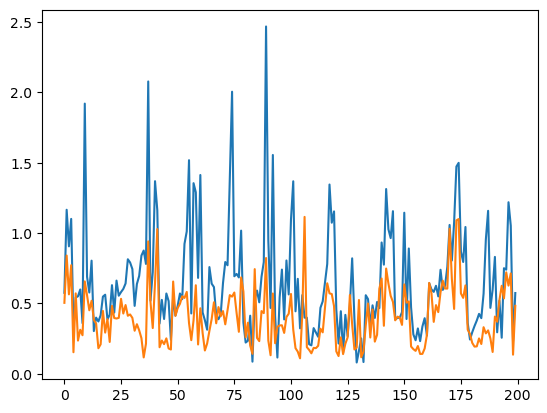

In [21]:
window_n = 5
window_size = 200
plt.plot(mod.true_flux[window_n*window_size:(1+window_n)*window_size])
plt.plot(mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])

In [22]:
# OR we can load and cut the actual fluxes to get realistic above-baseline concentrations

# loads the brazil map of fluxes
brazil_fluxes = load_default_brazil_emissions()

# load the true footprints to use the release_lat and release_lon,
# and select the same timepoints as the testing set
true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
true_fps = true_fps.sel(time=mod.preds_test.time)

cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
cut_flux = cut_flux.transpose([2,0,1])
# now cut_flux is in the same shape as mod.pred_fluxes["thr"], so we can plot it

In [23]:
mod.get_fluxes(cut_flux)

USING NO UNITS TRANSFORM on the fluxes! this may have changed


Text(0, 0.5, 'ppb')

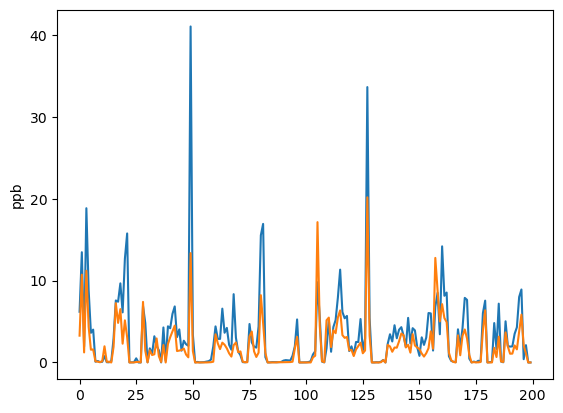

In [24]:
window_n = 3#window_n+1
window_size = 200
plt.plot(1e9*mod.true_flux[window_n*window_size:(1+window_n)*window_size])
plt.plot(1e9*mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
plt.ylabel("ppb")

# Now run over all models
# Footprints

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_B/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


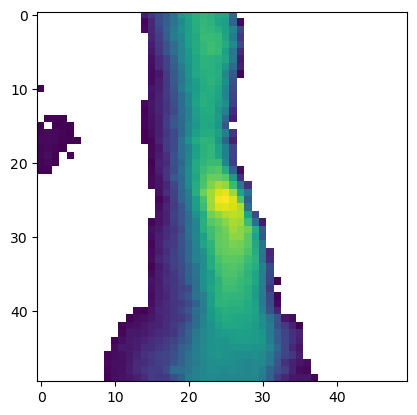

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


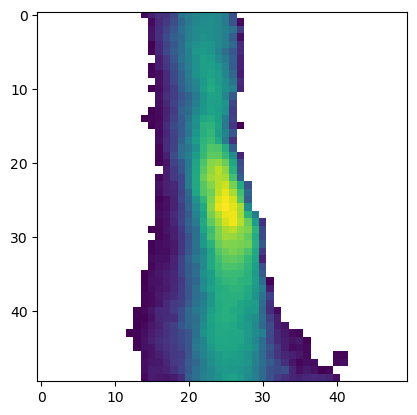

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed100/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


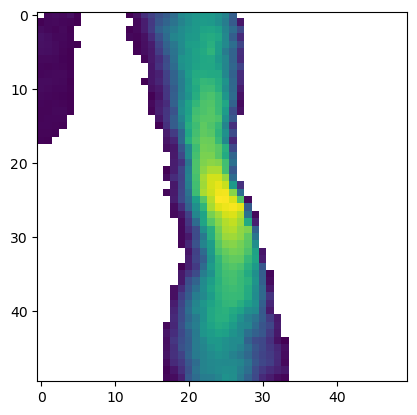

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed33/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


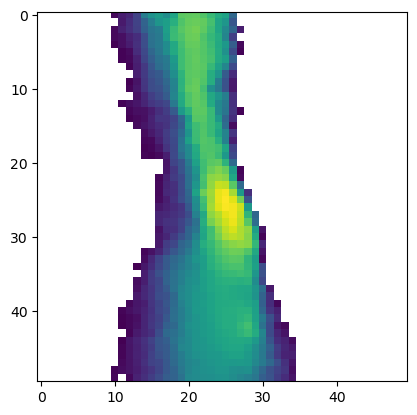

In [25]:
models = []
for name in model_names:
    print(name)

    mod = ModelEv(
        name,
        size=50,
        validation_set="0[1-3]",
        test_set="*",
        val_year="2016",
        test_year="2016",
        check_validation_overlap=True,
        path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/"
    )
    # threshold the model to remove the lower values. stores these predictions in mod.pred_fluxes["thr"]
    mod.get_adjusted_models(which="thr_only")

    plt.imshow(np.log10(mod.preds_test.thr[t]))
    plt.show()

    models.append(mod)

In [26]:
# Get all thresholded predictions and stack along a new "seed" dimension
thr_preds = xr.concat(
    [xr.DataArray(mod.preds_test.thr, dims=["time", "lat", "lon"]) for mod in models],
    dim="seed"
)

# Get the ground truth
fp = xr.DataArray(models[0].preds_test.fp, dims=["time", "lat", "lon"])

# Basic statistics

In [32]:
mean_pred = thr_preds.mean(dim="seed")


In [33]:
mean_pred

<xarray.DataArray 'thr' (time: 4243, lat: 50, lon: 50)>
array([[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         2.5074258e-05, 4.0144972e-05, 7.0410584e-05],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         4.6613412e-05, 4.4630742e-05, 5.3313575e-05],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         4.3593747e-05, 4.7355355e-05, 3.3220291e-05],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         4.2011999e-04, 4.0209811e-04, 3.9905056e-04],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         4.5316681e-04, 4.2798670e-04, 4.4546439e-04],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         5.0187431e-04, 4.6743007e-04, 4.5315892e-04]],

       [[9.3330306e-07, 7.4696294e-07, 7.3319944e-07, ...,
         1.7197017e-05, 1.9452847e-05, 2.1446966e-05],
        [1.5346761e-06, 1.3384636e-06, 6.9183858e-07, ...,
         1.7376809e-05, 1.9249052e-05, 2.0216579e-05],
        [6.7404733e-07, 6.3873631e-07, 6.4993594e-07, ...,
         1.9076779e-05, 2.0392343e-05, 2.0722870e-05],
...
        [2.1645043e-05, 2.2034572e-05, 2.2571367e-05, ...,
         4.7959775e-06, 4.7795043e-06, 5.0118570e-06],
        [1.9782075e-05, 1.9851463e-05, 2.0297268e-05, ...,
         4.5344423e-06, 4.6397759e-06, 4.7918152e-06],
        [1.8554234e-05, 1.8472376e-05, 2.0451724e-05, ...,
         3.9920046e-06, 4.2427728e-06, 4.9846853e-06]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         2.4214105e-06, 2.4123026e-06, 2.4159128e-06],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         3.5260155e-06, 2.6991615e-06, 2.3705443e-06],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         3.7057234e-06, 3.4092118e-06, 2.8915570e-06],
        ...,
        [1.5425226e-06, 1.5208627e-06, 1.1448051e-06, ...,
         2.0951775e-04, 2.2971394e-04, 2.4888944e-04],
        [1.9883166e-06, 1.6724574e-06, 1.3754502e-06, ...,
         1.8168031e-04, 1.9312896e-04, 2.5013307e-04],
        [1.9312656e-06, 1.6324925e-06, 1.3607914e-06, ...,
         1.3979909e-04, 1.4086306e-04, 2.3294172e-04]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2016-04-01T15:29:20 ... 2016-12-31T17:44:35
  * lat      (lat) int64 0 1 2 3 4 5 6 7 8 9 ... 40 41 42 43 44 45 46 47 48 49
  * lon      (lon) int64 0 1 2 3 4 5 6 7 8 9 ... 40 41 42 43 44 45 46 47 48 49

### Per timestep

In [ ]:
save_file_summary = save_path("uncertainty_summary_statistics.nc")
if os.path.exists(save_file_summary):
    print(f"Loading cached stats arrays from {save_file_summary}...")
    # Reopen the dataset
    summary_ds = xr.open_dataset(save_file_summary)

    # Extract variables as NumPy arrays
    mean_pred = summary_ds["mean_prediction"]
    std_pred = summary_ds["std_deviation"]
    cv_pred = summary_ds["coefficient_of_variation"]
    p5 = summary_ds["percentile_5"]
    p95 = summary_ds["percentile_95"]
    range_90 = summary_ds["range_90"]
    disagreement_mask = summary_ds["disagreement_zone"]

else:
    mean_pred = thr_preds.mean(dim="seed")
    std_pred = thr_preds.std(dim="seed")
    cv_pred = std_pred / (mean_pred + epsilon)
    q_vals = thr_preds.quantile([0.05, 0.95], dim="seed")
    p5 = q_vals.sel(quantile=0.05).drop_vars("quantile")
    p95 = q_vals.sel(quantile=0.95).drop_vars("quantile")
    range_90 = p95 - p5

    # Prediction disagreement zone (binary mask)
    disagreement_mask = (range_90 > disagreement_threshold)

    # Save summary statistics to NetCDF
    summary_ds = xr.Dataset({
        "mean_prediction": mean_pred,
        "std_deviation": std_pred,
        "coefficient_of_variation": cv_pred,
        "percentile_5": p5,
        "percentile_95": p95,
        "range_90": range_90,
        "disagreement_zone": disagreement_mask.astype("int")
    })
    summary_ds.to_netcdf(save_file_summary)
    print("Saved uncertainty_summary_statistics.nc")

Loading cached stats arrays from uncertainty/summary_outputs/uncertainty_summary_statistics.nc...


In [58]:
# Reopen the dataset
summary_ds = xr.open_dataset(save_path("uncertainty_summary_statistics.nc"))

# Extract variables as NumPy arrays
mean_pred = summary_ds["mean_prediction"]
std_pred = summary_ds["std_deviation"]
cv_pred = summary_ds["coefficient_of_variation"]
p5 = summary_ds["percentile_5"]
p95 = summary_ds["percentile_95"]
range_90 = summary_ds["range_90"]
disagreement_mask = summary_ds["disagreement_zone"]

In [20]:
# Prediction disagreement zone (binary mask)
disagreement_mask = (range_90 > disagreement_threshold)

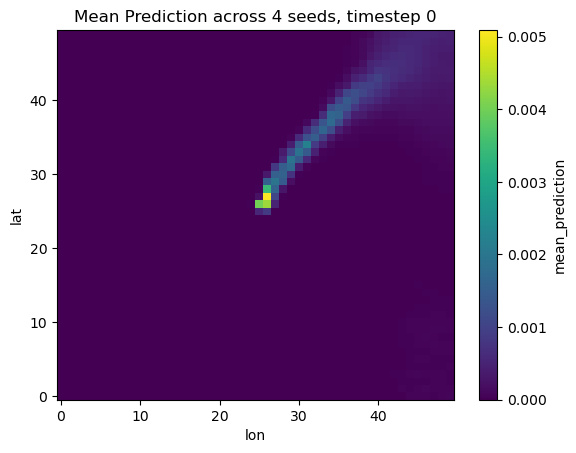

Saved Mean Prediction across 4 seeds, timestep 0.png


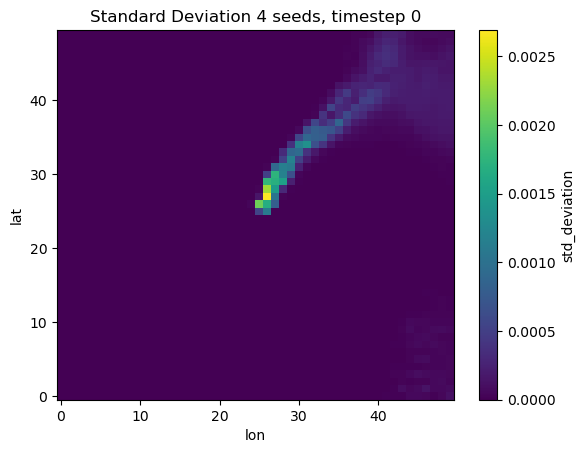

Saved Standard Deviation 4 seeds, timestep 0.png


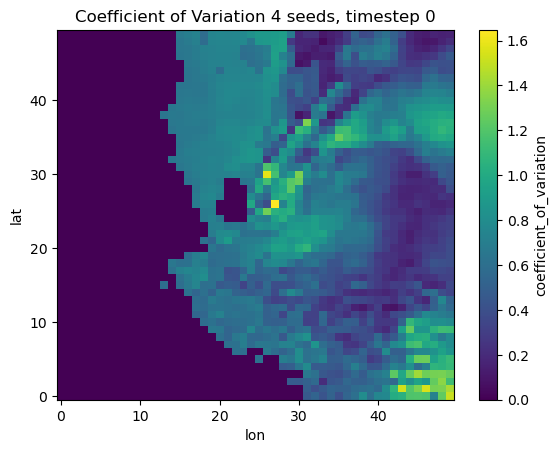

Saved Coefficient of Variation 4 seeds, timestep 0.png


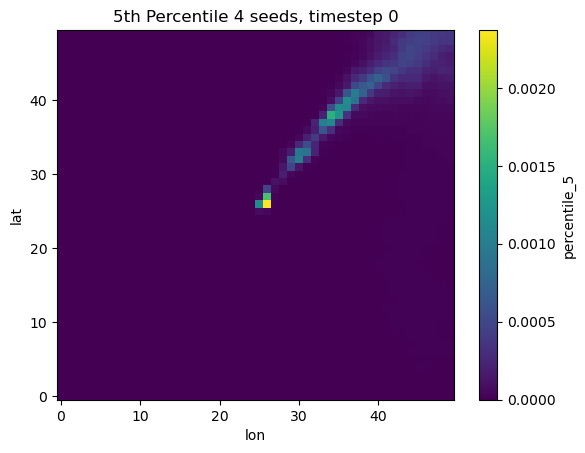

Saved 5th Percentile 4 seeds, timestep 0.png


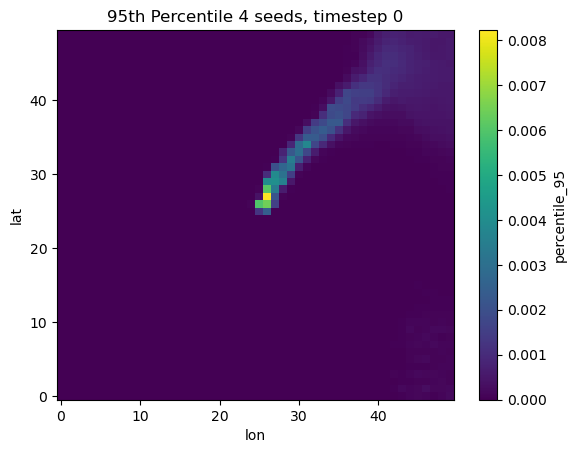

Saved 95th Percentile 4 seeds, timestep 0.png


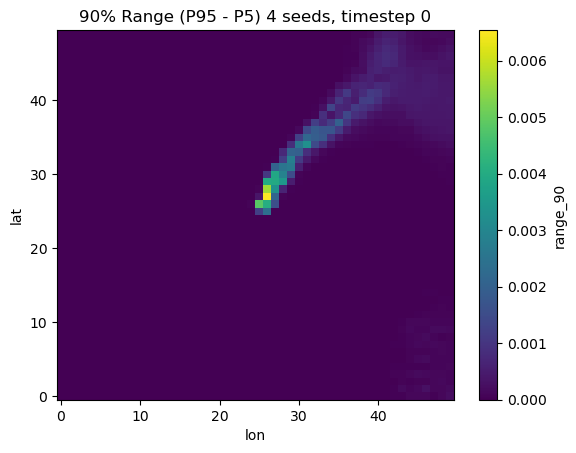

Saved 90% Range (P95 - P5) 4 seeds, timestep 0.png


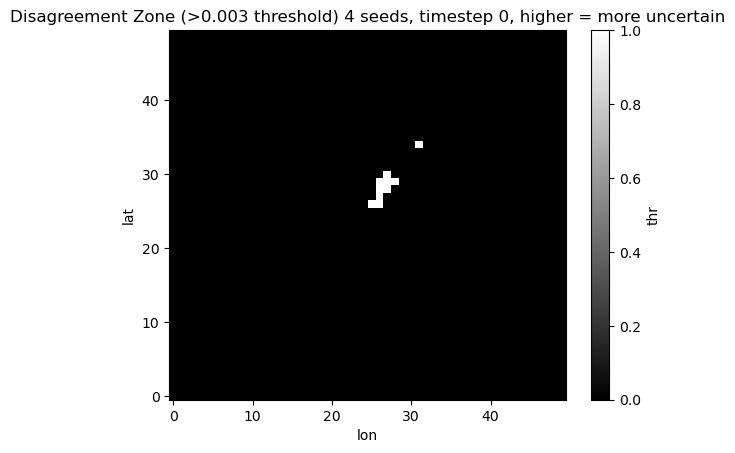

Saved Disagreement Zone (>0.003 threshold) 4 seeds, timestep 0, higher = more uncertain.png


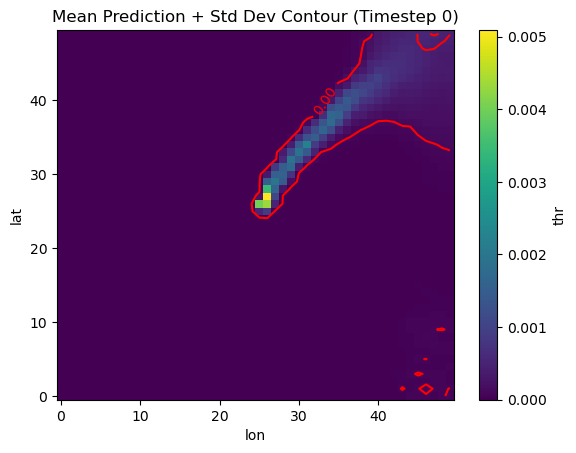

Saved mean_with_std_contour.png


In [21]:
num_models = len(models)

# Plot basic metrics
plots = {
    f"Mean Prediction across {num_models} seeds, timestep {single_time_step}": summary_ds["mean_prediction"],
    f"Standard Deviation {num_models} seeds, timestep {single_time_step}": summary_ds["std_deviation"],
    f"Coefficient of Variation {num_models} seeds, timestep {single_time_step}" : summary_ds["coefficient_of_variation"],
    f"5th Percentile {num_models} seeds, timestep {single_time_step}": summary_ds["percentile_5"],
    f"95th Percentile {num_models} seeds, timestep {single_time_step}": summary_ds["percentile_95"],
    f"90% Range (P95 - P5) {num_models} seeds, timestep {single_time_step}": summary_ds["range_90"],
    f"Disagreement Zone (>{disagreement_threshold} threshold) {num_models} seeds, timestep {single_time_step}, higher = more uncertain": disagreement_mask
}

for name, data in plots.items():
    plt.figure()
    if "time" in data.dims:
        data = data.isel(time=single_time_step)
    data.plot(cmap="viridis" if "Zone" not in name else "gray")
    plt.title(name)
    plt.savefig(save_path(name.replace(" ", "_").lower() + ".png"))
    plt.show()
    plt.close()
    print(f"Saved {name}.png")

# Uncertainty-weighted visualisation (mean + contour of standard deviation)
plt.figure()
mean_pred.isel(time=0).plot(cmap="viridis")  # reduce to 2D
cs = plt.contour(std_pred.isel(time=time_steps[0]), levels=[std_pred.mean().item()], colors="red")
plt.clabel(cs, fmt="%.2f", colors="red")
plt.title("Mean Prediction + Std Dev Contour (Timestep 0)")
plt.savefig(save_path("mean_with_std_contour.png"))
plt.show()
plt.close()
print("Saved mean_with_std_contour.png")



# Histograms showing distributions of uncertainty metrics
histograms = {
    "Standard Deviation": std_pred.values.flatten(),
    "Coefficient of Variation": cv_pred.values.flatten(),
    "90% Prediction Range": range_90.values.flatten()
}


#### --- Could rethreshold eg mean prediction?

### Compute errors

In [22]:
abs_error = abs(mean_pred - fp)

error_vs_uncertainty = xr.Dataset({
    "abs_error": abs_error,
    "std_deviation": std_pred
})
error_vs_uncertainty.to_netcdf(save_path("error_vs_uncertainty.nc"))
print("Saved error_vs_uncertainty.nc")
# Scatter correlation

err_flat = abs_error.values.flatten()
unc_flat = std_pred.values.flatten()

valid = ~np.isnan(err_flat) & ~np.isnan(unc_flat)
corr, pval = pearsonr(unc_flat[valid], err_flat[valid])
print(f"Pearson r between uncertainty and abs error: {corr:.3f} (p={pval:.2g})")


Saved error_vs_uncertainty.nc
Pearson r between uncertainty and abs error: 0.675 (p=0)


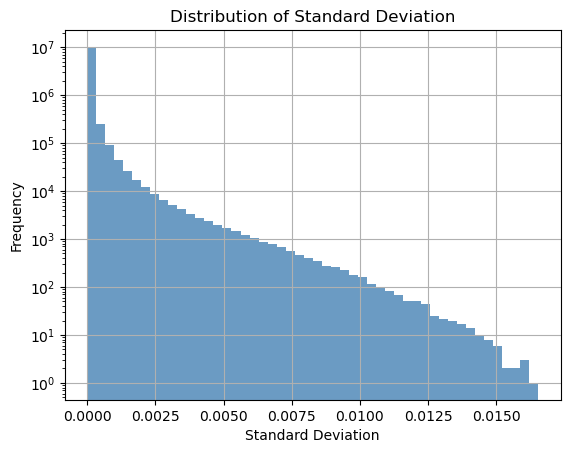

Saved hist_standard_deviation.png


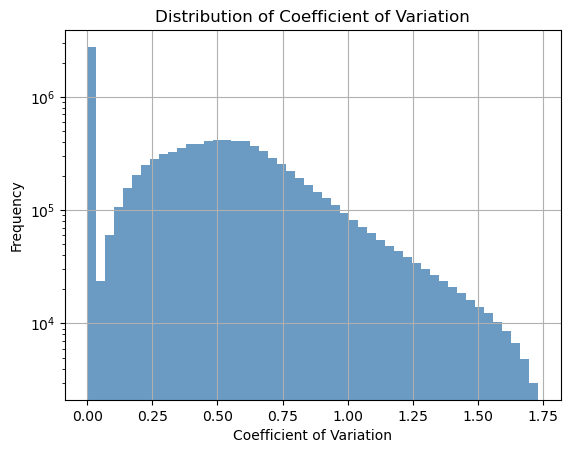

Saved hist_coefficient_of_variation.png


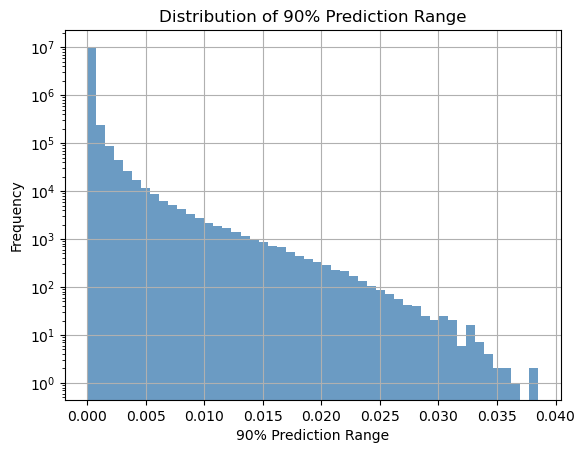

Saved hist_90%_prediction_range.png


In [24]:
# Histograms showing distributions of uncertainty metrics, aggregated over time
histograms = {
    "Standard Deviation": summary_ds["std_deviation"].values.flatten(),
    "Coefficient of Variation": summary_ds["coefficient_of_variation"].values.flatten(),
    "90% Prediction Range": summary_ds["range_90"].values.flatten()
}

for name, values in histograms.items():
    plt.figure()
    plt.hist(values, bins=50, color="steelblue", alpha=0.8)
    plt.yscale("log")
    plt.title(f"Distribution of {name}")
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.grid(True)
    filename = f"hist_{name.lower().replace(' ', '_')}.png"
    plt.savefig(save_path(filename))
    plt.show()
    plt.close()
    print(f"Saved {filename}")

## Mean fp

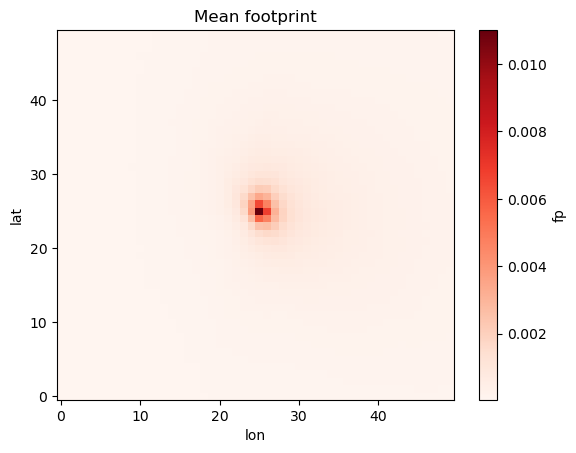

Saved nean_fp.png


In [25]:
mean_fp = fp.mean(dim="time")

# And average error
plt.figure()
mean_fp.plot.imshow(cmap="Reds")
plt.title("Mean footprint")
plt.savefig(save_path(f"mean_fp.png"))
plt.show()
plt.close()
print("Saved nean_fp.png")

In [26]:
## Plots vs fps

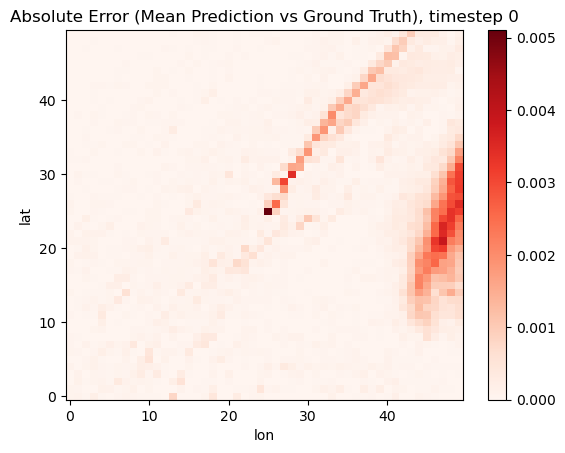

Saved abs_error.png


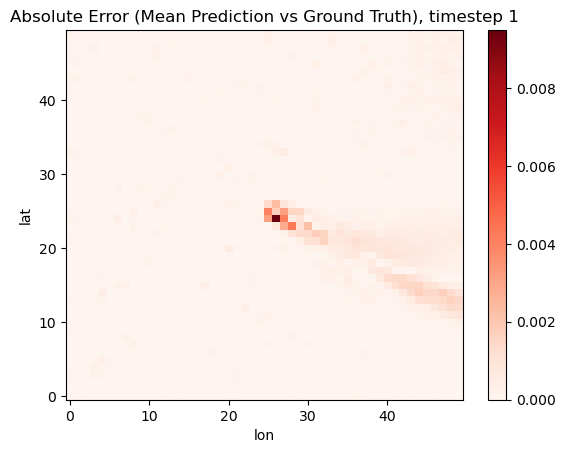

Saved abs_error.png


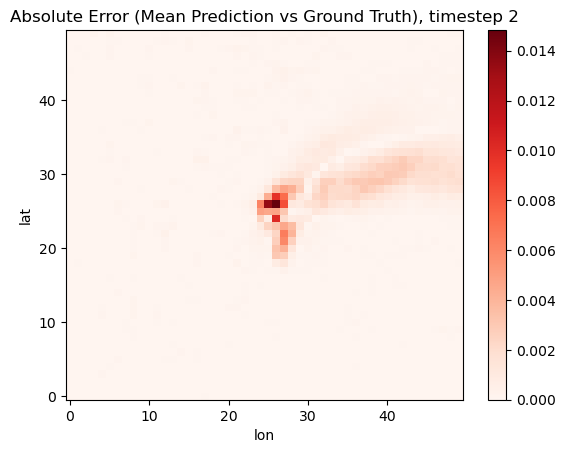

Saved abs_error.png


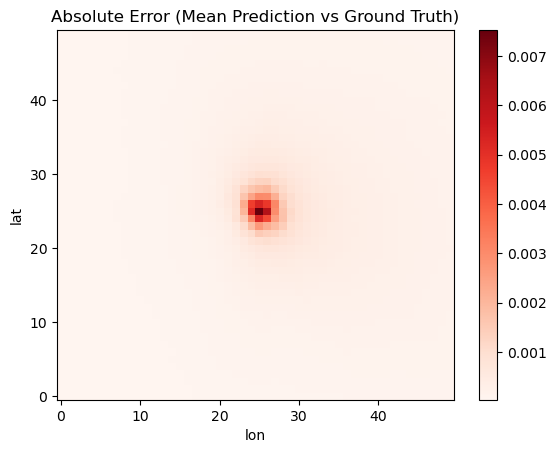

Saved abs_error.png


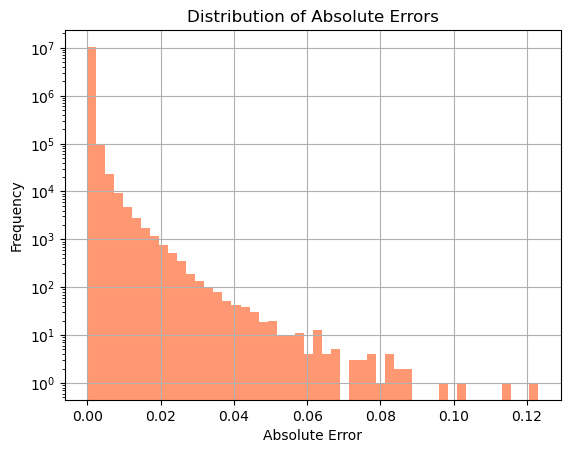

Saved hist_abs_error.png
Pearson correlation between uncertainty and error: 0.675 (p=0)


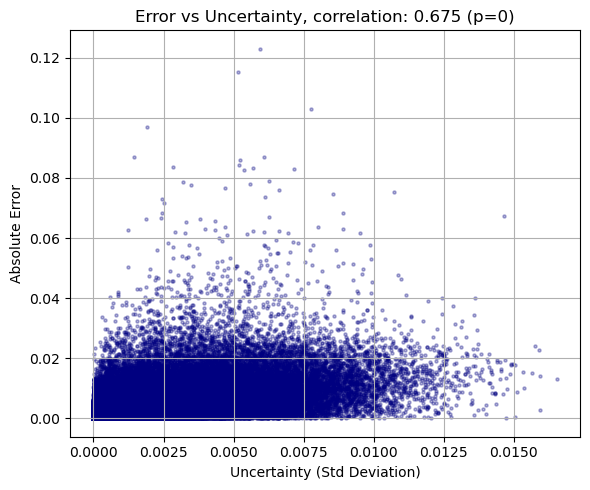

Saved scatter_error_vs_uncertainty.png


In [25]:
# Plot absolute error


for time_step in time_steps:
    plt.figure()
    abs_error.isel(time=time_step).plot.imshow(cmap="Reds")
    plt.title(f"Absolute Error (Mean Prediction vs Ground Truth), timestep {time_step}")
    plt.savefig(save_path(f"abs_error_time_{time_step}.png"))
    plt.show()
    plt.close()
    print("Saved abs_error.png")

# And average error
plt.figure()
abs_error.mean(dim="time").plot.imshow(cmap="Reds")
plt.title("Absolute Error (Mean Prediction vs Ground Truth)")
plt.savefig(save_path(f"abs_error_average.png"))
plt.show()
plt.close()
print("Saved abs_error.png")

# Histogram of absolute error
plt.figure()
plt.hist(abs_error.values.flatten(), bins=50, color="coral", alpha=0.8)
plt.title("Distribution of Absolute Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.yscale("log")
plt.grid(True)
plt.savefig(save_path("hist_abs_error.png"))
plt.show()
plt.close()
print("Saved hist_abs_error.png")

# Error vs uncertainty
# Flatten to 1D arrays
error_values = abs_error.values.flatten()
uncertainty_values = std_pred.values.flatten()

# Filter out NaNs (e.g. ocean regions / cropped regions if applicable)
valid = ~np.isnan(error_values) & ~np.isnan(uncertainty_values)
error_values = error_values[valid]
uncertainty_values = uncertainty_values[valid]

corr, p = pearsonr(uncertainty_values, error_values)
print(f"Pearson correlation between uncertainty and error: {corr:.3f} (p={p:.3g})")

# Create scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(uncertainty_values, error_values, alpha=0.3, s=5, c="navy")
plt.xlabel("Uncertainty (Std Deviation)")
plt.ylabel("Absolute Error")
plt.title(f"Error vs Uncertainty, correlation: {corr:.3f} (p={p:.3g})")
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("scatter_error_vs_uncertainty.png"))
plt.show()
plt.close()
print("Saved scatter_error_vs_uncertainty.png")




In [28]:
# Consider both spatial and temporal components

In [29]:
disagreement_freq = disagreement_mask.mean(dim="time")  # values between 0 and 1

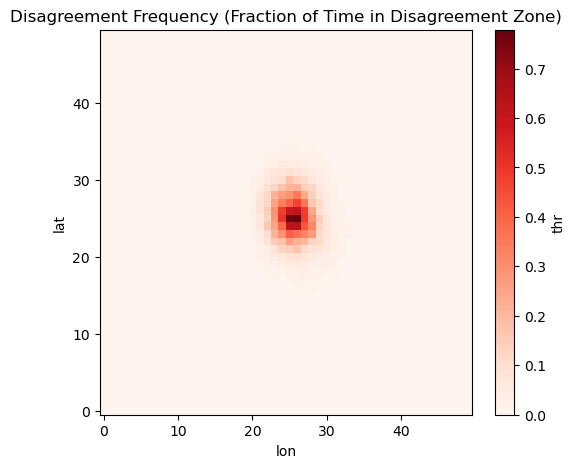

Saved disagreement_zone_frequency.png


In [30]:
plt.figure(figsize=(6, 5))
disagreement_freq.plot(cmap="Reds")
plt.title("Disagreement Frequency (Fraction of Time in Disagreement Zone)")
plt.savefig(save_path("disagreement_zone_frequency.png"))
plt.show()
plt.close()
print("Saved disagreement_zone_frequency.png")

In [31]:
## Temporal uncertainty

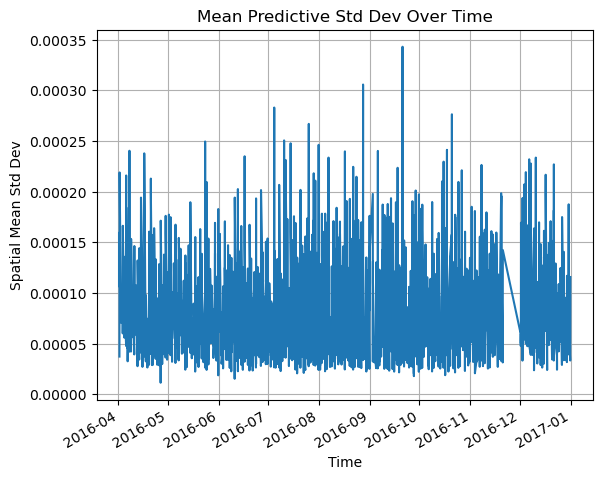

In [32]:
temporal_uncertainty = std_pred.mean(dim=("lat", "lon"))

plt.figure()
temporal_uncertainty.plot()
plt.title("Mean Predictive Std Dev Over Time")
plt.xlabel("Time")
plt.ylabel("Spatial Mean Std Dev")
plt.grid(True)
plt.savefig(save_path("temporal_std_dev.png"))
plt.show()
plt.close()


In [33]:
### Spatio-Temporal Consistency

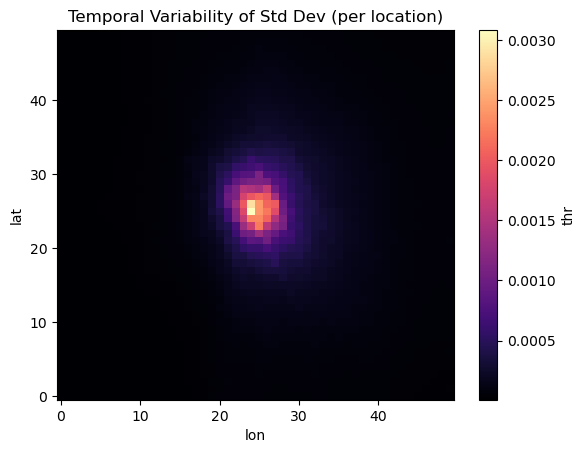

In [34]:
# Temporal standard deviation of uncertainty at each location
uncertainty_variability = std_pred.std(dim="time")

plt.figure()
uncertainty_variability.plot(cmap="magma")
plt.title("Temporal Variability of Std Dev (per location)")
plt.savefig(save_path("temporal_variability_uncertainty.png"))
plt.show()
plt.close()


In [35]:
### Animated uncertainty visulation

In [37]:
# These take a long time to run so I suggest not running them unless you want to see the animations
#animate_dataarray(mean_pred, "Mean Prediction", "mean_prediction.gif", cmap="viridis", save_dir=summary_dir)
#animate_dataarray(std_pred[0:100], "Standard Deviation[0:100]", "std_dev_over_time[0:100].gif", cmap="magma", save_dir=summary_dir)
#animate_dataarray(cv_pred[0:100], "Coefficient of Variation[0:100]", "cv_over_time[0:100].gif", cmap="cividis", save_dir=summary_dir)


## MAE compared to fps

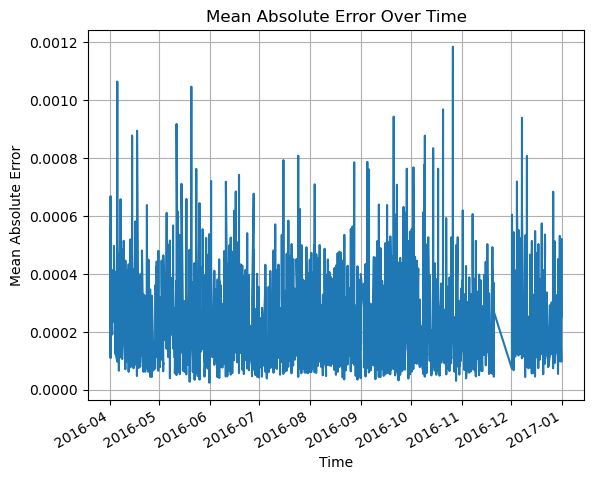

In [38]:
# Mean absolute error across space at each time step
temporal_mae = abs_error.mean(dim=("lat", "lon"))

# Plot
plt.figure()
temporal_mae.plot()
plt.title("Mean Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.savefig(save_path("temporal_mae.png"))
plt.show()
plt.close()


### Correlation Between Uncertainty and Error Over Time

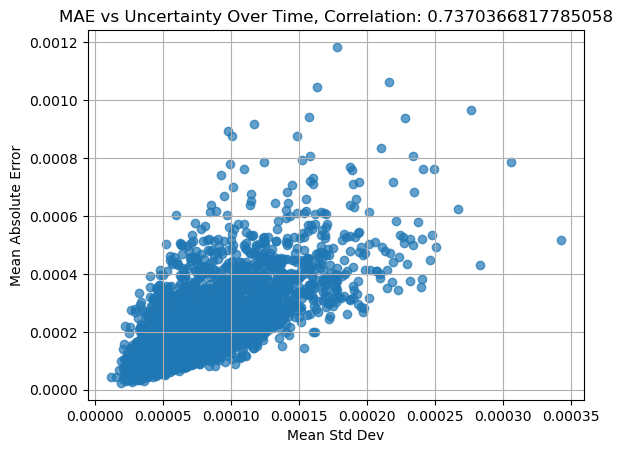

In [39]:
mae_over_time = abs_error.mean(dim=("lat", "lon"))
std_over_time = std_pred.mean(dim=("lat", "lon"))
corr_time = np.corrcoef(mae_over_time, std_over_time)[0, 1]

plt.figure()
plt.scatter(std_over_time, mae_over_time, alpha=0.7)
plt.title(f"MAE vs Uncertainty Over Time, Correlation: {corr_time}")
plt.xlabel("Mean Std Dev")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.savefig(save_path("mae_error_vs_uncertainty_time.png"))
plt.show()
plt.close()

### --- Run also for MSE?


# Fluxes

## Extract fluxes from all models

### fluxes using default uniform fluxes, ie summing over the footprints

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_B/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


using UNIFORM fluxes!
USING NO UNITS TRANSFORM on the fluxes! this may have changed


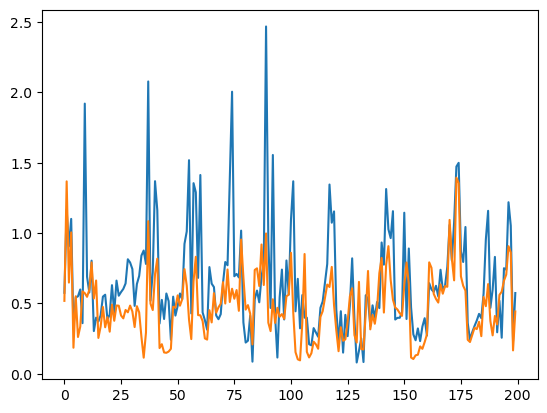

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


using UNIFORM fluxes!
USING NO UNITS TRANSFORM on the fluxes! this may have changed


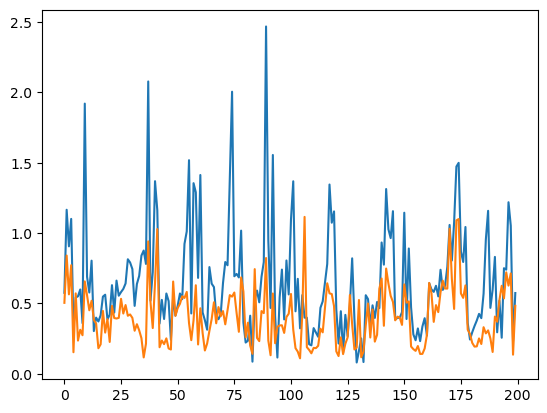

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed100/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


using UNIFORM fluxes!
USING NO UNITS TRANSFORM on the fluxes! this may have changed


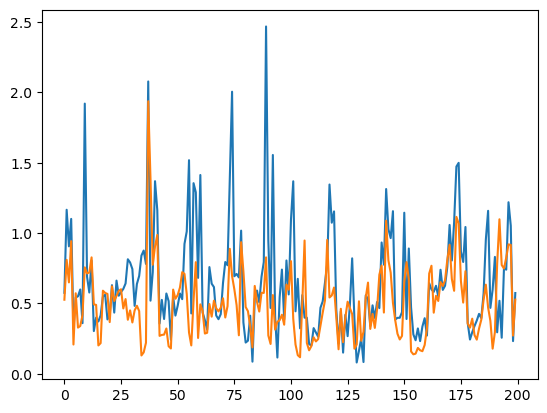

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed33/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


using UNIFORM fluxes!
USING NO UNITS TRANSFORM on the fluxes! this may have changed


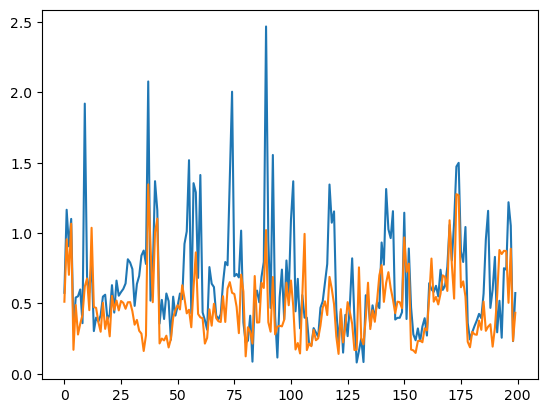

Saved flux arrays to fluxes.npz


In [7]:
save_file = "fluxes.npz"

if os.path.exists(save_file):
    print(f"Loading cached flux arrays from {save_file}...")
    data = np.load(save_file)
    pred_fluxes = data["pred"]
    true_fluxes = data["true"]
    print(f"Loaded shapes: pred={pred_fluxes.shape}, true={true_fluxes.shape}")

else:
    pred_fluxes = []
    true_fluxes = []

    for name in model_names:
        print(name)

        mod = ModelEv(
            name,
            size=50,
            validation_set="0[1-3]",
            test_set="*",
            val_year="2016",
            test_year="2016",
            check_validation_overlap=True,
            path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/"
        )
        mod.get_adjusted_models(which="thr_only")

        try:
            mod.get_fluxes()
            pred = mod.pred_fluxes.get("thr", None)
            true = getattr(mod, "true_flux", None)

            window_n = 5
            window_size = 200
            plt.plot(mod.true_flux[window_n*window_size:(1+window_n)*window_size])
            plt.plot(mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
            plt.show()

            if pred is not None and true is not None:
                pred_fluxes.append(pred)
                true_fluxes.append(true)
            else:
                print(f"Skipping model {mod.model_name} — fluxes missing")

        except Exception as e:
            print(f"Error processing model {mod.model_name}: {e}")

    # Stack and save
    pred_fluxes = np.stack(pred_fluxes, axis=0)  # shape: (models, time)
    true_fluxes = np.stack(true_fluxes, axis=0)
    np.savez_compressed(save_file, pred=pred_fluxes, true=true_fluxes)

    print(f"Saved flux arrays to {save_file}")


In [8]:
window_n = 5
window_size = 200
start = window_n * window_size
end = (window_n + 1) * window_size


## Overlay all models

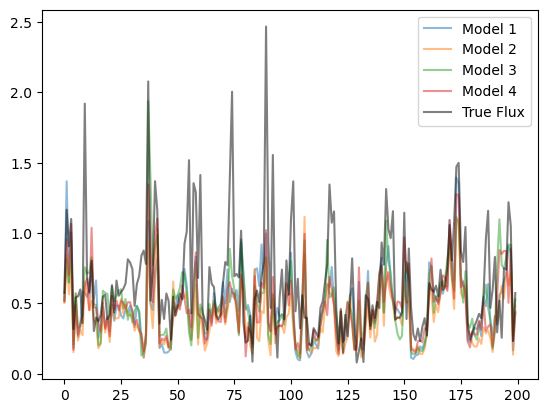

In [7]:
pred_fluxes = np.stack(pred_fluxes, axis=0)  # shape: (n_models, time)
true_fluxes = np.stack(true_fluxes, axis=0)

for i in range(pred_fluxes.shape[0]):
    plt.plot(pred_fluxes[i, start:end], alpha=0.5, label=f"Model {i+1}")

plt.plot(true_fluxes[0, start:end], alpha=0.5, color="black", label="True Flux")
plt.legend()
plt.savefig(save_path("flux_timeseries_overlay.png"))


## Compute stats

In [9]:
mean_flux = np.mean(pred_fluxes, axis=0)  # shape: (time,)
std_flux = np.std(pred_fluxes, axis=0)    # shape: (time,)
mean_true = np.mean(true_fluxes, axis=0)  # Optional: mean ground truth across models
normalised_mean_flux = mean_flux/mean_true # normalised to the true footprint magnitude
normalised_std_flux = std_flux/mean_true # normalised to the true footprint magnitude

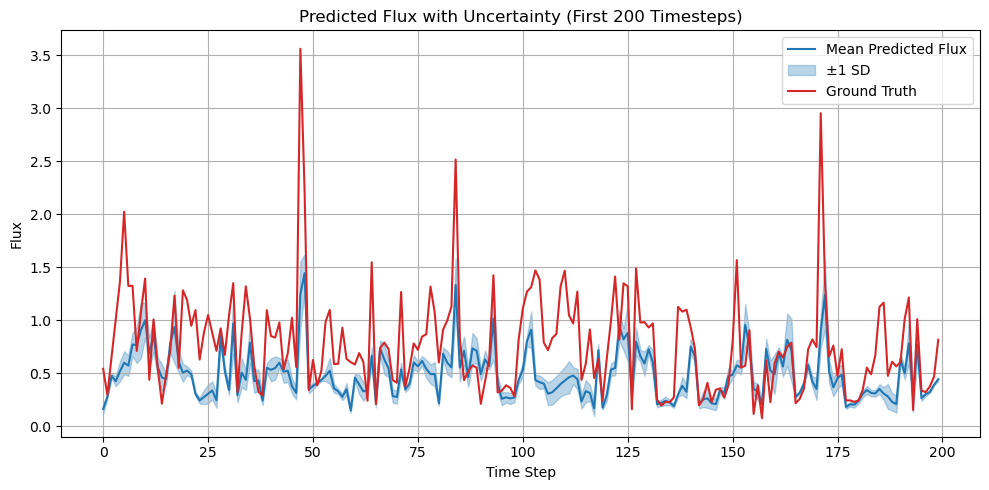

In [11]:
# Define number of time steps to plot
n_steps = 200

# Slice data arrays
mean_flux_subset = mean_flux[:n_steps]
std_flux_subset = std_flux[:n_steps]
mean_true_subset = mean_true[:n_steps]
normalised_mean_flux_subset = normalised_mean_flux[:n_steps]
normalised_std_flux_subset = normalised_std_flux[:n_steps]
time = np.arange(n_steps)

# Plot
plt.figure(figsize=(10, 5))

# Plot mean predicted flux with uncertainty band
plt.plot(time, mean_flux_subset, label="Mean Predicted Flux", color="tab:blue")
plt.fill_between(time, 
                 mean_flux_subset - std_flux_subset, 
                 mean_flux_subset + std_flux_subset, 
                 alpha=0.3, color="tab:blue", label="±1 SD")

# Plot ground truth
plt.plot(time, mean_true_subset, label="Ground Truth", color="tab:red")

plt.title(f"Predicted Flux with Uncertainty (First {n_steps} Timesteps)")
plt.xlabel("Time Step")
plt.ylabel("Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("flux_timeseries_uncertainty.png"))
plt.show()

### - NEW - Plot normalised fluxes

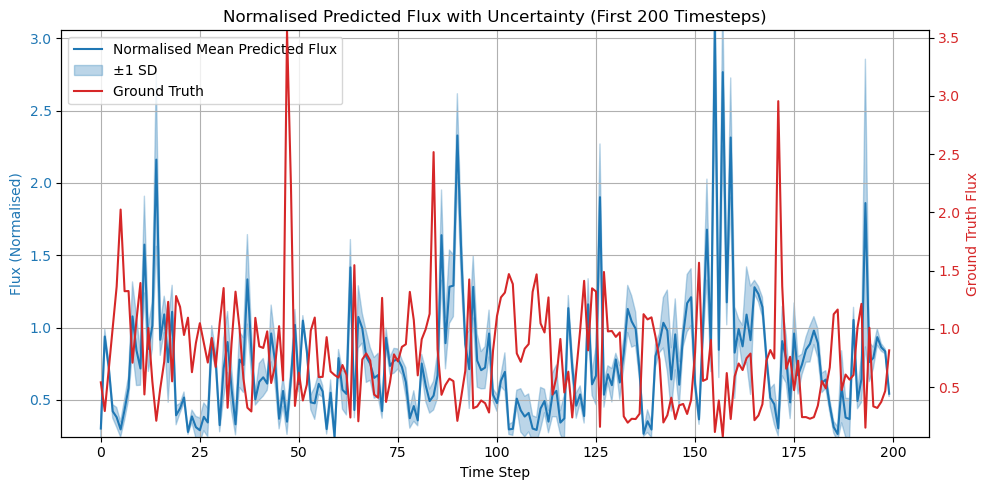

In [12]:
# Create figure and main axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot mean predicted flux with uncertainty band on the left y-axis
ax1.plot(time, normalised_mean_flux_subset, label="Normalised Mean Predicted Flux", color="tab:blue")
ax1.fill_between(time,
                 normalised_mean_flux_subset - normalised_std_flux_subset,
                 normalised_mean_flux_subset + normalised_std_flux_subset,
                 alpha=0.3, color="tab:blue", label="±1 SD")

ax1.set_xlabel("Time Step")
ax1.set_ylabel("Flux (Normalised)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Create a second y-axis on the right
ax2 = ax1.twinx()

# --- Align scales ---
# Map the range of mean_true_subset to the left axis range
left_min, left_max = normalised_mean_flux_subset.min(), normalised_mean_flux_subset.max()
right_min, right_max = mean_true_subset.min(), mean_true_subset.max()

# Scale ground truth so trends match left axis visually
scaled_ground_truth = ((mean_true_subset - right_min) / (right_max - right_min)) * (left_max - left_min) + left_min

# Plot the scaled version on the same visual scale
ax2.plot(time, mean_true_subset, label="Ground Truth", color="tab:red")
ax2.set_ylabel("Ground Truth Flux", color="tab:red")
ax2.tick_params(axis='y', labelcolor="tab:red")

# Adjust right y-axis limits to match left axis visually
ax2.set_ylim(right_min, right_max)
ax1.set_ylim(left_min, left_max)

# Title and grid
plt.title(f"Normalised Predicted Flux with Uncertainty (First {n_steps} Timesteps)")
ax1.grid(True)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(save_path("normalised_flux_timeseries_uncertainty.png"))
plt.show()


In [13]:
## Now find the 20 time steps with the largest uncertainty, and the lowest

In [43]:
top_n = 10
highest_uncertainty_indices = np.argsort(std_flux)[-top_n:][::-1]  # descending order
lowest_uncertainty_indices = np.argsort(std_flux)[:top_n]  # descending order

In [44]:
for i in highest_uncertainty_indices:
    print(f"Time step {i}: std = {std_flux[i]:.4f}, mean flux = {mean_flux[i]:.4f}")
    abs_error = np.abs(mean_flux - mean_true)
    print(f"Abs error at time {i}: {abs_error[i]:.4f}")


Time step 2476: std = 0.5780, mean flux = 1.7246
Abs error at time 2476: 0.5592
Time step 2924: std = 0.5520, mean flux = 1.8561
Abs error at time 2924: 0.2387
Time step 1764: std = 0.4496, mean flux = 1.3859
Abs error at time 1764: 0.2006
Time step 3414: std = 0.4292, mean flux = 1.6223
Abs error at time 3414: 1.7088
Time step 1339: std = 0.4040, mean flux = 1.2474
Abs error at time 1339: 0.6262
Time step 727: std = 0.4026, mean flux = 1.5957
Abs error at time 727: 0.5404
Time step 93: std = 0.3868, mean flux = 1.0147
Abs error at time 93: 0.4100
Time step 3946: std = 0.3851, mean flux = 1.1409
Abs error at time 3946: 1.7651
Time step 1434: std = 0.3839, mean flux = 1.3114
Abs error at time 1434: 0.8214
Time step 2399: std = 0.3820, mean flux = 1.2857
Abs error at time 2399: 0.5440


### Lowest uncertainty fluxes

In [45]:
for i in lowest_uncertainty_indices:
    print(f"Time step {i}: std = {std_flux[i]:.4f}, mean flux = {mean_flux[i]:.4f}")
    abs_error = np.abs(mean_flux - mean_true)
    print(f"Abs error at time {i}: {abs_error[i]:.4f}")


Time step 250: std = 0.0032, mean flux = 0.2062
Abs error at time 250: 0.0503
Time step 3141: std = 0.0034, mean flux = 0.2216
Abs error at time 3141: 0.2836
Time step 3984: std = 0.0036, mean flux = 0.2293
Abs error at time 3984: 0.1124
Time step 1644: std = 0.0037, mean flux = 0.1505
Abs error at time 1644: 0.0046
Time step 1822: std = 0.0038, mean flux = 0.2017
Abs error at time 1822: 0.1306
Time step 3966: std = 0.0044, mean flux = 0.1341
Abs error at time 3966: 0.0026
Time step 2897: std = 0.0046, mean flux = 0.1614
Abs error at time 2897: 0.0162
Time step 2514: std = 0.0051, mean flux = 0.8196
Abs error at time 2514: 0.0867
Time step 627: std = 0.0053, mean flux = 0.1604
Abs error at time 627: 0.0380
Time step 1969: std = 0.0061, mean flux = 0.1348
Abs error at time 1969: 0.1061


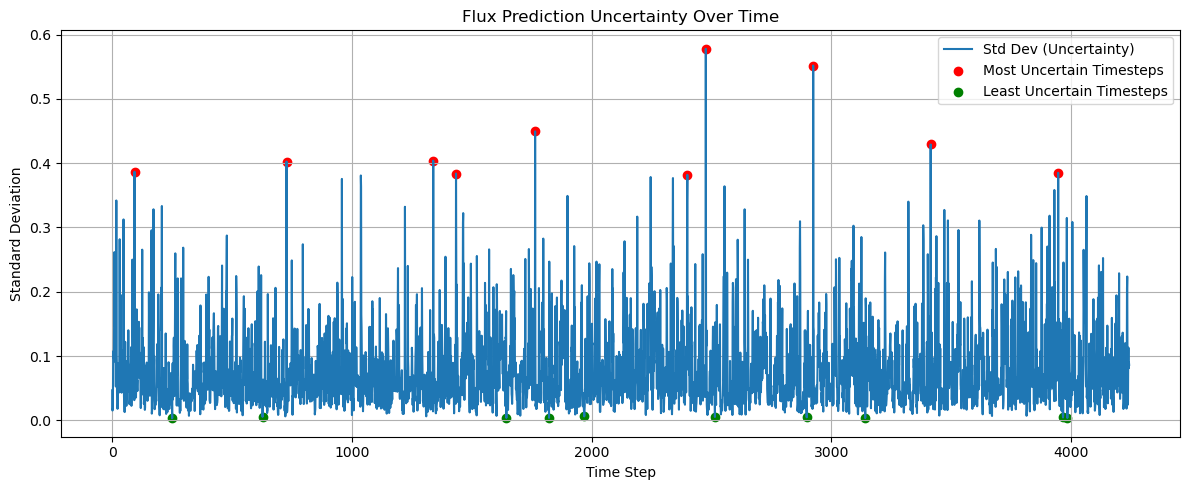

In [46]:
time = np.arange(len(std_flux))
plt.figure(figsize=(12, 5))
plt.plot(time, std_flux, label="Std Dev (Uncertainty)", color="tab:blue")

# Highlight top uncertain timesteps
plt.scatter(highest_uncertainty_indices, std_flux[highest_uncertainty_indices], color="red", label="Most Uncertain Timesteps")
plt.scatter(lowest_uncertainty_indices, std_flux[lowest_uncertainty_indices], color="green", label="Least Uncertain Timesteps")


plt.title("Flux Prediction Uncertainty Over Time")
plt.xlabel("Time Step")
plt.ylabel("Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("flux_timeseries_with_high_low_uncertainty.png"))
plt.show()

## Now load and cut the actual fluxes to get realistic above-baseline concentrations

In [14]:
# loads the brazil map of fluxes
brazil_fluxes = load_default_brazil_emissions()

# load the true footprints to use the release_lat and release_lon,
# and select the same timepoints as the testing set
true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
true_fps = true_fps.sel(time=mod.preds_test.time)

cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
cut_flux = cut_flux.transpose([2,0,1])
# now cut_flux is in the same shape as mod.pred_fluxes["thr"], so we can plot it
mod.get_fluxes(cut_flux)

USING NO UNITS TRANSFORM on the fluxes! this may have changed


satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_B/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


USING NO UNITS TRANSFORM on the fluxes! this may have changed


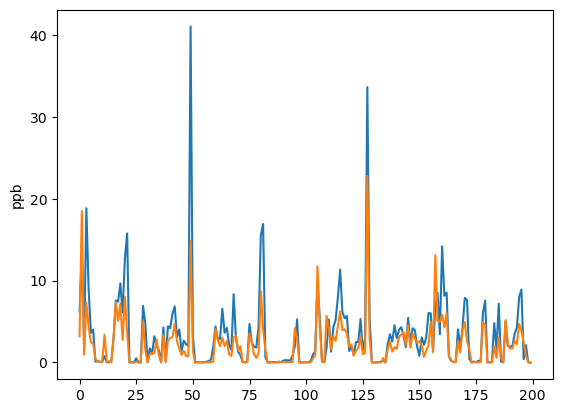

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


USING NO UNITS TRANSFORM on the fluxes! this may have changed


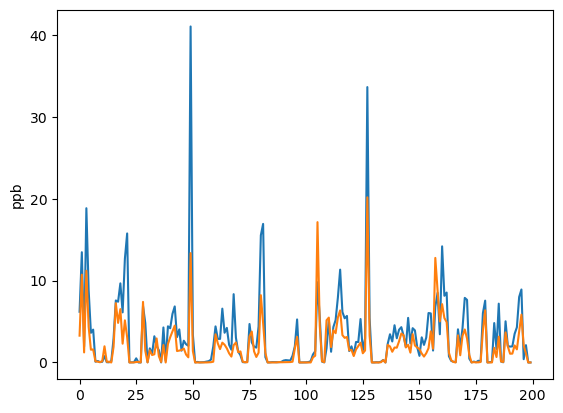

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed100/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


USING NO UNITS TRANSFORM on the fluxes! this may have changed


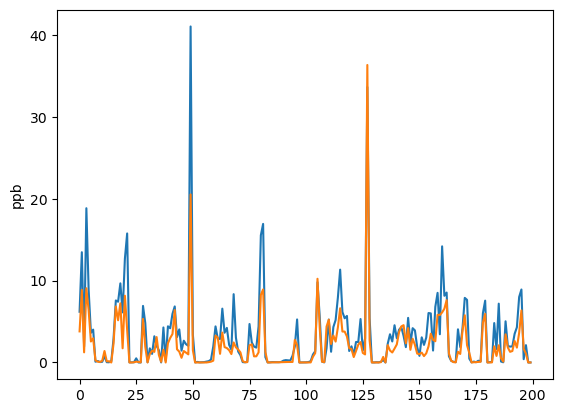

satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33
loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed33/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


USING NO UNITS TRANSFORM on the fluxes! this may have changed


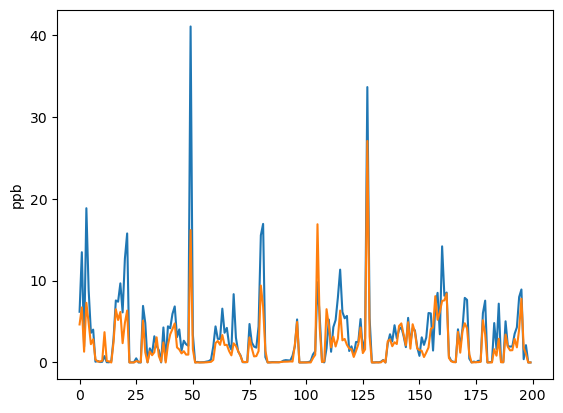

Saved flux arrays to fluxes_above_baseline.npz


In [15]:
save_file = "fluxes_above_baseline.npz"

if os.path.exists(save_file):
    print(f"Loading cached flux arrays from {save_file}...")
    data = np.load(save_file)
    pred_fluxes = data["pred"]
    true_fluxes = data["true"]
    print(f"Loaded shapes: pred={pred_fluxes.shape}, true={true_fluxes.shape}")

else:
    pred_fluxes = []
    true_fluxes = []

    for name in model_names:
        print(name)

        mod = ModelEv(
            name,
            size=50,
            validation_set="0[1-3]",
            test_set="*",
            val_year="2016",
            test_year="2016",
            check_validation_overlap=True,
            path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/"
        )
        # Threshold the model to remove the lower values
        mod.get_adjusted_models(which="thr_only")

        # Load the Brazil map of fluxes
        brazil_fluxes = load_default_brazil_emissions()

        # Load the true footprints and select same timepoints as testing set
        true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
        true_fps = true_fps.sel(time=mod.preds_test.time)

        # Cut flux to match footprint release locations
        cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
        cut_flux = cut_flux.transpose([2, 0, 1])

        # Compute fluxes with cut data
        mod.get_fluxes(cut_flux)

        pred = mod.pred_fluxes.get("thr", None)
        true = getattr(mod, "true_flux", None)

        # Optional quick visual check
        window_n = 3
        window_size = 200
        plt.plot(1e9 * mod.true_flux[window_n*window_size:(1+window_n)*window_size])
        plt.plot(1e9 * mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
        plt.ylabel("ppb")
        plt.show()

        if pred is not None and true is not None:
            pred_fluxes.append(pred)
            true_fluxes.append(true)
        else:
            print(f"Skipping model {mod.model_name} — fluxes missing")

    # Stack and save
    pred_fluxes = np.stack(pred_fluxes, axis=0)  # shape: (models, time)
    true_fluxes = np.stack(true_fluxes, axis=0)
    np.savez_compressed(save_file, pred=pred_fluxes, true=true_fluxes)

    print(f"Saved flux arrays to {save_file}")


In [16]:
window_n = 5
window_size = 200
start = window_n * window_size
end = (window_n + 1) * window_size

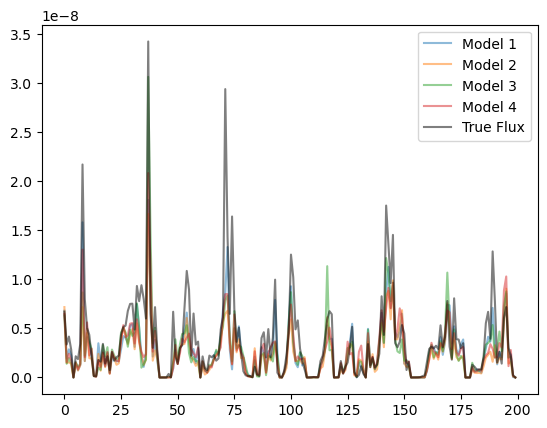

In [17]:
pred_fluxes = np.stack(pred_fluxes, axis=0)  # shape: (n_models, time)
true_fluxes = np.stack(true_fluxes, axis=0)

for i in range(pred_fluxes.shape[0]):
    plt.plot(pred_fluxes[i, start:end], alpha=0.5, label=f"Model {i+1}")

plt.plot(true_fluxes[0, start:end], alpha=0.5, color="black", label="True Flux")
plt.legend()
plt.savefig(save_path("flux_timeseries_overlay_truefp.png"))

## Compute stats

In [21]:
mean_flux = np.mean(pred_fluxes, axis=0)  # shape: (time,)
std_flux = np.std(pred_fluxes, axis=0)    # shape: (time,)
mean_true = np.mean(true_fluxes, axis=0)  # Optional: mean ground truth across models
normalised_mean_flux = mean_flux/mean_true # normalised to the true footprint magnitude
normalised_std_flux = std_flux/mean_true # normalised to the true footprint magnitude

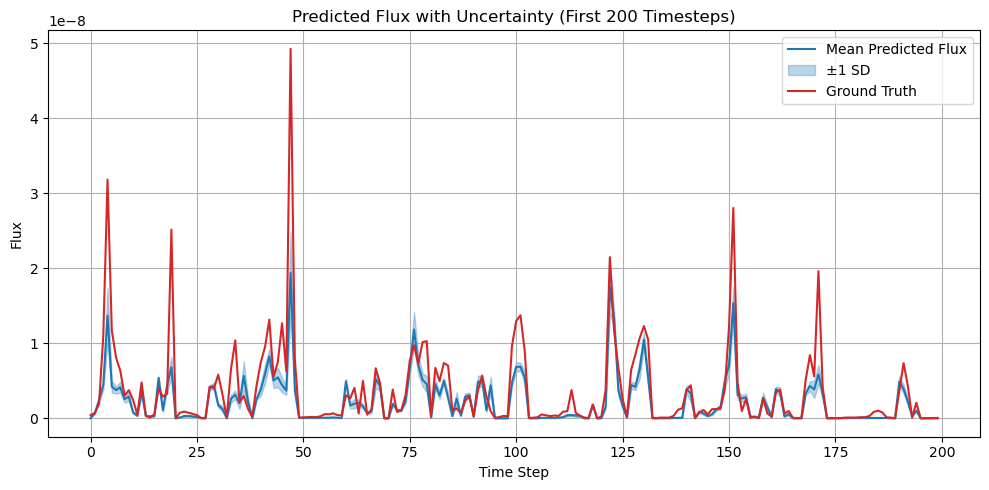

In [22]:
# Define number of time steps to plot
n_steps = 200

# Slice data arrays
mean_flux_subset = mean_flux[:n_steps]
std_flux_subset = std_flux[:n_steps]
mean_true_subset = mean_true[:n_steps]
normalised_mean_flux_subset = normalised_mean_flux[:n_steps]
normalised_std_flux_subset = normalised_std_flux[:n_steps]
time = np.arange(n_steps)

# Plot
plt.figure(figsize=(10, 5))

# Plot mean predicted flux with uncertainty band
plt.plot(time, mean_flux_subset, label="Mean Predicted Flux", color="tab:blue")
plt.fill_between(time, 
                 mean_flux_subset - std_flux_subset, 
                 mean_flux_subset + std_flux_subset, 
                 alpha=0.3, color="tab:blue", label="±1 SD")

# Plot ground truth
plt.plot(time, mean_true_subset, label="Ground Truth", color="tab:red")

plt.title(f"Predicted Flux with Uncertainty (First {n_steps} Timesteps)")
plt.xlabel("Time Step")
plt.ylabel("Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("flux_timeseries_uncertainty_true.png"))
plt.show()


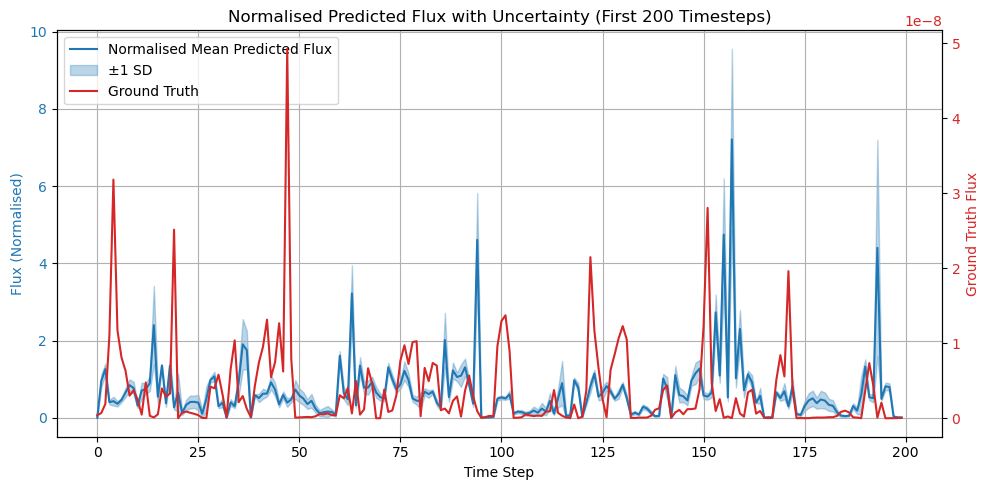

In [23]:
# Create figure and main axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot mean predicted flux with uncertainty band on the left y-axis
ax1.plot(time, normalised_mean_flux_subset, label="Normalised Mean Predicted Flux", color="tab:blue")
ax1.fill_between(time,
                 normalised_mean_flux_subset - normalised_std_flux_subset,
                 normalised_mean_flux_subset + normalised_std_flux_subset,
                 alpha=0.3, color="tab:blue", label="±1 SD")

ax1.set_xlabel("Time Step")
ax1.set_ylabel("Flux (Normalised)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Create a second y-axis on the right
ax2 = ax1.twinx()

# --- Align scales ---
# Map the range of mean_true_subset to the left axis range
left_min, left_max = normalised_mean_flux_subset.min(), normalised_mean_flux_subset.max()
right_min, right_max = mean_true_subset.min(), mean_true_subset.max()

# Scale ground truth so trends match left axis visually
scaled_ground_truth = ((mean_true_subset - right_min) / (right_max - right_min)) * (left_max - left_min) + left_min

# Plot the scaled version on the same visual scale
ax2.plot(time, mean_true_subset, label="Ground Truth", color="tab:red")
ax2.set_ylabel("Ground Truth Flux", color="tab:red")
ax2.tick_params(axis='y', labelcolor="tab:red")

# Adjust right y-axis limits to match left axis visually
#ax2.set_ylim(right_min, right_max)
#ax1.set_ylim(left_min, left_max)

# Title and grid
plt.title(f"Normalised Predicted Flux with Uncertainty (First {n_steps} Timesteps)")
ax1.grid(True)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(save_path("normalised_flux_timeseries_uncertainty_above_baseline.png"))
plt.show()


## Now find the 10 time steps with the largest uncertainty, and the lowest

In [24]:
top_n = 10
highest_uncertainty_indices = np.argsort(normalised_std_flux)[-top_n:][::-1]  # descending order
lowest_uncertainty_indices = np.argsort(normalised_std_flux)[:top_n]  # descending order

for i in highest_uncertainty_indices:
    print(f"Time step {i}: std = {std_flux[i]:.4f}, mean flux = {mean_flux[i]:.4f}")
    abs_error = np.abs(mean_flux - mean_true)
    print(f"Abs error at time {i}: {abs_error[i]:.4f}")

for i in lowest_uncertainty_indices:
    print(f"Time step {i}: std = {std_flux[i]:.4f}, mean flux = {mean_flux[i]:.4f}")
    abs_error = np.abs(mean_flux - mean_true)
    print(f"Abs error at time {i}: {abs_error[i]:.4f}")

Time step 2353: std = 0.0000, mean flux = 0.0000
Abs error at time 2353: 0.0000
Time step 944: std = 0.0000, mean flux = 0.0000
Abs error at time 944: 0.0000
Time step 2354: std = 0.0000, mean flux = 0.0000
Abs error at time 2354: 0.0000
Time step 486: std = 0.0000, mean flux = 0.0000
Abs error at time 486: 0.0000
Time step 3524: std = 0.0000, mean flux = 0.0000
Abs error at time 3524: 0.0000
Time step 485: std = 0.0000, mean flux = 0.0000
Abs error at time 485: 0.0000
Time step 487: std = 0.0000, mean flux = 0.0000
Abs error at time 487: 0.0000
Time step 626: std = 0.0000, mean flux = 0.0000
Abs error at time 626: 0.0000
Time step 2440: std = 0.0000, mean flux = 0.0000
Abs error at time 2440: 0.0000
Time step 488: std = 0.0000, mean flux = 0.0000
Abs error at time 488: 0.0000
Time step 298: std = 0.0000, mean flux = 0.0000
Abs error at time 298: 0.0000
Time step 165: std = 0.0000, mean flux = 0.0000
Abs error at time 165: 0.0000
Time step 1095: std = 0.0000, mean flux = 0.0000
Abs err

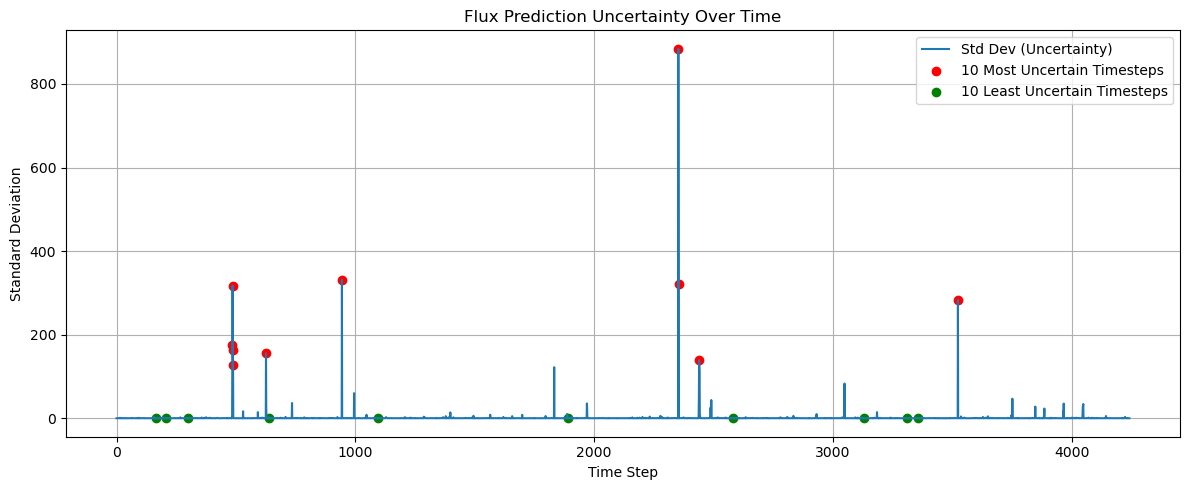

In [26]:
time = np.arange(len(normalised_std_flux))
plt.figure(figsize=(12, 5))
plt.plot(time, normalised_std_flux, label="Std Dev (Uncertainty)", color="tab:blue")

# Highlight top uncertain timesteps
plt.scatter(highest_uncertainty_indices, normalised_std_flux[highest_uncertainty_indices], color="red", label=f"{top_n} Most Uncertain Timesteps")
plt.scatter(lowest_uncertainty_indices, normalised_std_flux[lowest_uncertainty_indices], color="green", label=f"{top_n} Least Uncertain Timesteps")


plt.title("Flux Prediction Uncertainty Over Time")
plt.xlabel("Time Step")
plt.ylabel("Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("flux_timeseries_with_high_low_uncertainty_true.png"))
plt.show()

# 1. Time - seasonal analysis, starting with fluxes

# 2. Space - Disaggregated map of errors

In [41]:
std_pred.lon

<xarray.DataArray 'lon' (lon: 50)>
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])
Coordinates:
  * lon      (lon) int64 0 1 2 3 4 5 6 7 8 9 ... 40 41 42 43 44 45 46 47 48 49

[-60.981 -60.747 -60.513 -60.279 -60.045 -59.811 -59.577 -59.343 -59.109
 -58.875 -58.641 -58.407 -58.173 -57.939 -57.705 -57.471 -57.237 -57.003
 -56.769 -56.535 -56.301 -56.067 -55.833 -55.599 -55.365 -55.131 -54.897
 -54.663 -54.429 -54.195 -53.961 -53.727 -53.493 -53.259 -53.025 -52.791
 -52.557 -52.323 -52.089 -51.855 -51.621 -51.387 -51.153 -50.919 -50.685
 -50.451 -50.217 -49.983 -49.749 -49.515 -49.281 -49.047 -48.813 -48.579
 -48.345 -48.111 -47.877 -47.643 -47.409 -47.175 -46.941 -46.707 -46.473
 -46.239 -46.005 -45.771 -45.537 -45.303 -45.069 -44.835 -44.601 -44.367
 -44.133 -43.899 -43.665 -43.431 -43.197 -42.963 -42.729 -42.495 -42.261
 -42.027 -41.793 -41.559 -41.325 -41.091 -40.857 -40.623 -40.389 -40.155
 -39.921 -39.687 -39.453 -39.219 -38.985 -38.751 -38.517 -38.283 -38.049
 -37.815 -37.581 -37.347 -37.113 -36.879 -36.645 -36.411 -36.177 -35.943
 -35.709 -35.475 -35.241 -35.007 -34.773 -34.539 -34.305 -34.071 -33.837
 -33.603 -33.369 -33.135 -32.901 -32.667 -32.433 -3

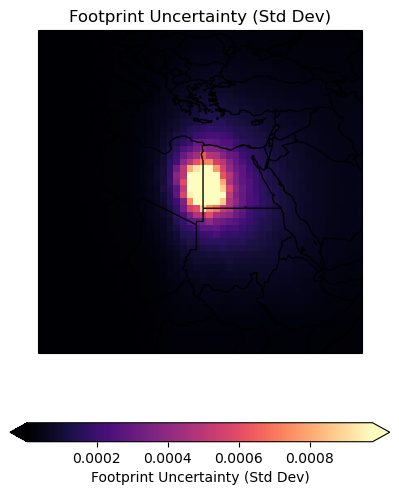

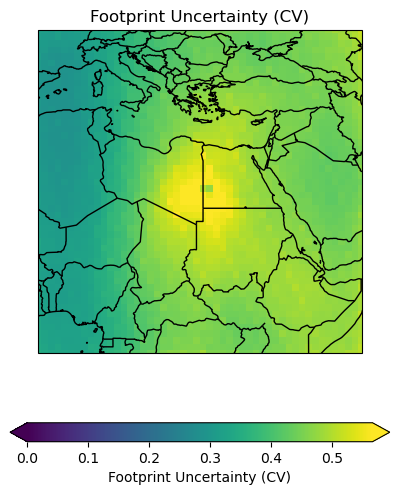

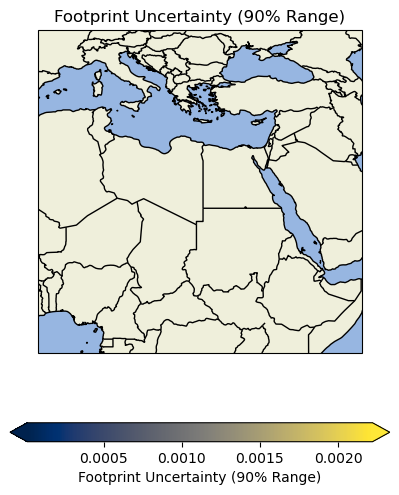

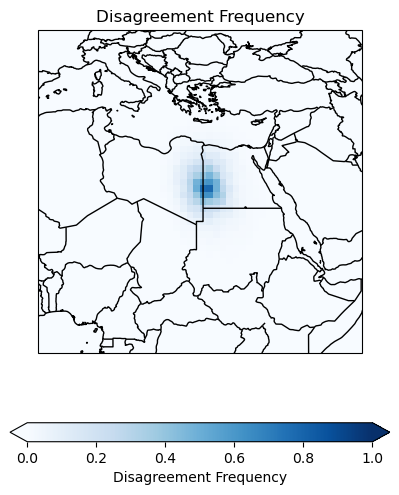

In [56]:
# Choose an uncertainty layer (2D), eg
unc_std  = std_pred.mean(dim="time")              # mean predictive std dev over time  (lat x lon)
unc_cv   = cv_pred.mean(dim="time")               # mean coefficient of variation      (lat x lon)
unc_rng  = range_90.mean(dim="time")              # mean 90% prediction range          (lat x lon)
disc_frq = disagreement_mask.mean(dim="time")     # frequency of disagreement          (lat x lon), in [0,1]

# Coordinates
month="*"
year="2016"
real = xr.open_mfdataset(glob.glob(f"/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_{year}{month}.nc"))
domain_lats = real.lat.values
domain_lons = real.lon.values
release_lats=real.release_lat.values
release_lons = real.release_lon.values
print(domain_lats, domain_lons)

domain_lats = unc_std.lat.values
domain_lons = unc_std.lon.values
binned_lons, binned_lats = np.meshgrid(domain_lons, domain_lats)



# Plot: std deviation (good for “how uncertain are we?”)
fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(
    ax=ax,
    binned_lons=binned_lons,
    binned_lats=binned_lats,
    metric=unc_std.values,
    metric_name="Footprint Uncertainty (Std Dev)",
    domain_lats=domain_lats,
    domain_lons=domain_lons,
    divergent=False,
    cmap="magma",                     
    vmin_vmax=[np.nanpercentile(unc_std, 1), np.nanpercentile(unc_std, 99)],
    fig=fig,
    cbar=True,
    cbar_position="bottom"
)
plt.savefig(save_path("footprint_uncertainty_std_map.png"), dpi=200)
plt.show()

# Plot: coefficient of variation (scale-free)
fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(
    ax=ax,
    binned_lons=binned_lons,
    binned_lats=binned_lats,
    metric=unc_cv.values,
    metric_name="Footprint Uncertainty (CV)",
    domain_lats=domain_lats,
    domain_lons=domain_lons,
    divergent=False,
    cmap="viridis",
    vmin_vmax=[0, np.nanpercentile(unc_cv, 99)],
    fig=fig,
    cbar=True
)
plt.savefig(save_path("footprint_uncertainty_cv_map.png"), dpi=200)
plt.show()

# Plot: 90% range (P95-P05)
fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(
    ax=ax,
    binned_lons=binned_lats,  # typo guard: keep lons/lats consistent!
    binned_lats=binned_lats,
    metric=unc_rng.values,
    metric_name="Footprint Uncertainty (90% Range)",
    domain_lats=domain_lats,
    domain_lons=domain_lons,
    divergent=False,
    cmap="cividis",
    vmin_vmax=[np.nanpercentile(unc_rng, 1), np.nanpercentile(unc_rng, 99)],
    fig=fig,
    cbar=True
)
plt.savefig(save_path("footprint_uncertainty_range90_map.png"), dpi=200)
plt.show()

# Plot: disagreement frequency (0–1)
fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(
    ax=ax,
    binned_lons=binned_lons,
    binned_lats=binned_lats,
    metric=disc_frq.values,
    metric_name="Disagreement Frequency",
    domain_lats=domain_lats,
    domain_lons=domain_lons,
    divergent=False,
    cmap="Blues",
    vmin_vmax=[0, 1],
    fig=fig,
    cbar=True
)
plt.savefig(save_path("disagreement_frequency_map.png"), dpi=200)
plt.show()
